In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

In [26]:
results = pd.read_csv("../runs/results_evaluate_all_v3.csv", header = None, names = ["System", "Query", "Metric", "Value"])
results

,System,Query,Metric,Value
0,bm25 % 100,1,NSR@500,0.571429
1,bm25 % 100,1,NSR@100,0.571429
2,bm25 % 100,1,NSR@1000,0.571429
3,bm25 % 100,1,sens_docs@10,1.000000
4,bm25 % 100,1,sens_docs@20,3.000000
...,...,...,...,...
30523,splade_sans % 500 >> filter % 100 >> get_text ...,99,sens_docs@20,0.000000
30524,splade_sans % 500 >> filter % 100 >> get_text ...,99,nCSDCG_cut_10,0.819563
30525,splade_sans % 500 >> filter % 100 >> get_text ...,99,nCSDCG_cut_20,0.830695
30526,splade_sans % 500 >> filter % 100 >> get_text ...,99,nDCG@10,0.335697


In [39]:
def categorise(input):
    if "get_text" in input and "% 500" not in input and "% 1000" not in input:
        return "three"
    if ">>" not in input:
        return "one"
        
results["category"] = results["System"].apply(categorise)
pipelines_csdcg = results[(results["category"] == "three") & (results["Metric"] == "nCSDCG_cut_10")]
pipelines_sens_docs = results[(results["category"] == "three") & (results["Metric"] == "sens_docs@10")]

In [40]:
unrepeated = results[(results["category"] == "one") & (results["Metric"] == "NSR@100")].copy()
first_stage = (
    unrepeated.groupby('System', group_keys=False)
    .apply(lambda group: pd.concat([group]*3, ignore_index=True))
)
first_stage

/tmp/ipykernel_8875/955330105.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unrepeated.groupby('System', group_keys=False)


,System,Query,Metric,Value,category
0,bm25 % 100,1,NSR@100,0.571429,one
1,bm25 % 100,10,NSR@100,1.000000,one
2,bm25 % 100,100,NSR@100,1.000000,one
3,bm25 % 100,101,NSR@100,0.600000,one
4,bm25 % 100,102,NSR@100,0.214286,one
...,...,...,...,...,...
313,splade_sans % 100,95,NSR@100,0.153846,one
314,splade_sans % 100,96,NSR@100,0.652174,one
315,splade_sans % 100,97,NSR@100,0.733333,one
316,splade_sans % 100,98,NSR@100,0.833333,one


In [42]:
for sys in zip(pipelines_csdcg.System.tolist(), first_stage.System.tolist()):
    assert sys[0].startswith(sys[1])

In [45]:
ncsdcg_10 = pipelines_csdcg[pipelines_csdcg["Metric"] == "nCSDCG_cut_10"].Value.tolist()
sens_docs_10 = pipelines_sens_docs[pipelines_sens_docs["Metric"] == "sens_docs@10"].Value.tolist()
nsr_100 = first_stage[first_stage["Metric"] == "NSR@100"].Value.tolist()

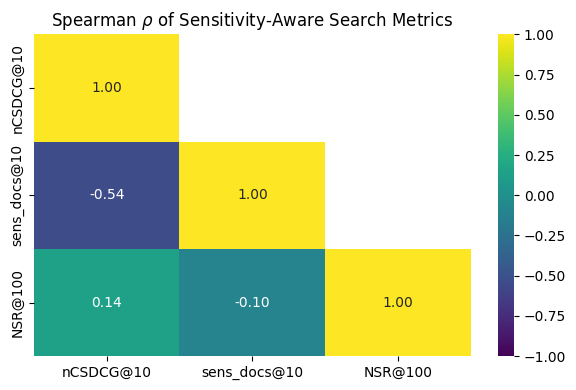

In [48]:
# Create the metrics DataFrame
df_metrics = pd.DataFrame({
    'nCSDCG@10': ncsdcg_10,
    'sens_docs@10': sens_docs_10,
    'NSR@100': nsr_100
})

# Compute full Pearson correlation matrix
corr = df_metrics.corr(method='spearman')

# Mask the undesired cells by setting them to NaN
mask = {
    ('nCSDCG@10', 'sens_docs@10'),
    ('nCSDCG@10', 'NSR@100'),
    ('sens_docs@10', 'NSR@100')
}
for i, j in mask:
    corr.loc[i, j] = np.nan

# Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='viridis', vmin=-1, vmax=1, fmt=".2f", mask=corr.isna(), cbar=True)
plt.title(r"Spearman $\rho$ of Sensitivity-Aware Search Metrics")
plt.tight_layout()
plt.savefig("./metric_correlations_spearman_with_first_stage.png", dpi = 1080)
# plt.show()